## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [ ]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2
# !pip install torch torchvision torchaudio torchtext scipy scikit-plot

In [ ]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [ ]:
# !pip install scipy==1.9.3
# !pip install scipy==1.8.0
# !pip install scikit-plot
#you may receive a message of restarting session, this is OK

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.8.0 (from versions: 

In [3]:
!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import libraries

In [1]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
# import scikitplot as skplt
# import gc
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu" )
print(device)

mps


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [3]:
train_dataset, test_dataset = AG_NEWS()

In [4]:
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [9]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [10]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [11]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [12]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [13]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [14]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [46]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    """
        This function is passed to the torch.Dataset and it is executed when the dataset is processed.
        In short, this functions creates a tuple with two elements, 
            * First is an array of indexes with a size of 50 indexes (controlled by the variable max_token). The indexes are determine by the function tokeniser. 
            * Second is the real or expected value of the prediction or what is normally call y. 
        Given that some of the texts have less than 50 elements the functions completes with zero the indexes in this way we can have the same size no matter if the sentences is shorter and if there are 
        some differences in the number of words or tokens
        For the variable Y the function reduce in 1 the value it has, this is done as we want to use those values as indexes that can be tied to the a list of the corresponding text label.
    """
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [16]:
LABELS =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

In [17]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [18]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [ ]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        self.layers = layers
        self.hidden = hidden
        # Se define la capa embedding_layer, y esta capa se encarga de determinar un numero de "caracteristicas"
        # Determinado por el numero o tamaño de embeddings en este caso 300 y el numero unico de tokens unicos. dado
        # por el parametro num_embeddings.
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                            embedding_dim=embed_size)

        # self.rnn = None # complete this code/
        #                 # You may use PyTorch nn.GRU(), nn.RNN(), or nn.LSTM()

        # # Create a GRU layer
        # # Parameters
        # input_size = 5     # Number of features per time step
        # hidden_size = 3    # Number of features in hidden state
        # num_layers = 2     # Number of stacked GRU layers
        # seq_len = 50       # Sequence length
        # batch_size = 2     # Number of sequences in a batch
        self.gru = nn.GRU(
            input_size=embed_size,  # número de features, dado que esta dado por el numero de dimensiones de los embeddings sera 300
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True  # Input/output tensors have shape (batch, seq, feature)
        )


        # self.fc = None# complete output classifier layer using linear layer
        # self.fc = nn.Linear(embed_size, num_classes)
        self.fc = nn.Linear(hidden, num_classes)




    def forward(self, x):
        # Forward pass

        # Initial hidden state zeros,  por ahora asumo
        # Numero de capas (que es 2),
        # Batch size (Que es 256 o más pequeño si es el ultimo batch)
        # Numero de hiddens que corresponde con el #. de embeddings
        self.hidden_state = torch.zeros(self.layers, x.size()[0], self.hidden, device=device)

        # El primer paso del forward, debe ser transformar el input (los tokens) en un arreglo de 3 dimensiones.
        # con las siguientes dimensiones - # (batch_size, sequence_length, embedding_dim) que para el caso default es 256, 50, 300
        x = self.embedding_layer(x)

        # Detach the hidden state to prevent backpropagating through previous batches
        x, self.hidden_state = self.gru(x, self.hidden_state) # We execute the rrn.
        # To fix the error, we need to take the output from the last time step
        x = x[:, -1, :] # x now has shape (batch_size, hidden_size)
        # x, test = self.gru(x_embeddings, self.hidden_state) # We execute the rrn.
        x = self.fc(x)
        return x
        # implement forward pass. This function will be called when executing the model

In [20]:
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
print(rnn_model)

RNN_Model_1(
  (embedding_layer): Embedding(95811, 300)
  (gru): GRU(300, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


In [21]:
def accuracy(model, loader):
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (xi, yi) in loader:
            xi = xi.to(device=device, dtype = torch.long)
            yi = yi.to(device=device, dtype = torch.long)
            scores = model(xi) # mb_size, 10
            _, pred = scores.max(dim=1) #pred shape (mb_size )
            num_correct += (pred == yi).sum() # pred shape (mb_size), yi shape (mb_size, 1)
            num_total += pred.size(0)
        return float(num_correct)/num_total

In [22]:
def train(model, optimiser, epochs=100):
#     def train(model, optimiser, scheduler = None, epochs=100):
    model = model.to(device=device)
    for epoch in range(epochs):
        for (xi, yi) in train_loader:
            model.train()
            xi = xi.to(device=device, dtype=torch.torch.long)
            xi.size()
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)

            cost = F.cross_entropy(input= scores, target=yi)

            optimiser.zero_grad()
            cost.backward()
            optimiser.step()

        acc = accuracy(model, val_loader)
#         if epoch%5 == 0:
        print(f'Epoch: {epoch}, costo: {cost.item()}, accuracy: {acc},')
#         scheduler.step()

In [23]:
epochs = 10
lr = 1e-4
# instantiate model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

In [24]:
train(rnn_model, optimiser=optimiser,  epochs=epochs)

Epoch: 0, costo: 0.617252767086029, accuracy: 0.775,
Epoch: 1, costo: 0.338738352060318, accuracy: 0.85975,
Epoch: 2, costo: 0.27866214513778687, accuracy: 0.87975,
Epoch: 3, costo: 0.340352326631546, accuracy: 0.8925,
Epoch: 4, costo: 0.19122980535030365, accuracy: 0.8933333333333333,
Epoch: 5, costo: 0.13033552467823029, accuracy: 0.8965,
Epoch: 6, costo: 0.17947611212730408, accuracy: 0.8968333333333334,
Epoch: 7, costo: 0.16589252650737762, accuracy: 0.90125,
Epoch: 8, costo: 0.18440623581409454, accuracy: 0.9001666666666667,
Epoch: 9, costo: 0.17916390299797058, accuracy: 0.9000833333333333,


In [41]:
for (xi, yi) in train_loader:
  print(xi, yi)
  break

tensor([[ 8683,    12,  6513,  ...,     0,     0,     0],
        [ 8198,    12,     9,  ...,     0,     0,     0],
        [ 1700,     4,   274,  ...,     0,     0,     0],
        ...,
        [21751,    12,     9,  ...,     0,     0,     0],
        [  333, 10932,  1150,  ...,     0,     0,     0],
        [  303,   183,    21,  ...,     0,     0,     0]], dtype=torch.int32) tensor([3, 1, 3, 0, 2, 3, 0, 0, 2, 2, 0, 0, 0, 1, 2, 3, 0, 1, 2, 0, 3, 1, 2, 0,
        1, 1, 0, 1, 2, 2, 3, 1, 0, 1, 2, 0, 0, 1, 2, 3, 1, 3, 2, 0, 1, 2, 3, 0,
        1, 2, 2, 2, 2, 1, 2, 3, 1, 2, 2, 0, 3, 3, 1, 0, 3, 2, 2, 0, 0, 0, 2, 1,
        0, 0, 3, 1, 0, 1, 3, 2, 0, 3, 1, 3, 0, 0, 3, 1, 1, 0, 1, 2, 0, 1, 1, 2,
        3, 1, 0, 1, 2, 0, 3, 2, 0, 2, 0, 1, 1, 1, 1, 0, 1, 3, 1, 0, 3, 0, 3, 3,
        3, 3, 3, 1, 0, 2, 3, 0, 2, 2, 2, 2, 1, 1, 1, 2, 3, 3, 2, 2, 0, 1, 3, 1,
        2, 0, 1, 0, 2, 0, 2, 2, 1, 2, 1, 0, 3, 0, 0, 3, 3, 3, 2, 1, 3, 0, 1, 2,
        2, 1, 3, 3, 0, 0, 0, 1, 2, 0, 3, 3, 3, 3, 1, 1, 1, 

In [25]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9011


In [43]:
def sample_text(model, loader):

    model = model.to(device=device)

    y_pred = np.array([])
    y_test = np.array([])


    model.eval()
    with torch.no_grad():
        for (xi,yi) in loader:

            xi = xi.to(device=device, dtype=torch.long)
            # yi = yi.to(device=device, dtype=torch.long)
            y_test = np.concatenate((y_test, yi.detach().numpy()))
            raw_outputs = model(xi)

            # print(f"Shape of the raw output: {raw_outputs.shape}")
            # print(f"Raw output tensor (logits) for the first text:\n{raw_outputs[0]}")

            probabilities = torch.softmax(raw_outputs, dim=1)
            # print(f"\nProbabilities for the first text:\n{probabilities[0]}")
            # print(f"Sum of probabilities for the first text: {torch.sum(probabilities[0])}") # Should be ~1.0

            # To get the final predicted class for each text in the batch, use argmax.
            predictions = torch.argmax(probabilities, dim=1)
            # print(f"\nFinal predicted class indices for the batch: {predictions}") # e.g., tensor([2, 9, 2, 5])
            y_pred = np.concatenate((y_pred, predictions.detach().cpu().numpy()))

    return (y_test, y_pred)


In [44]:
(y_test, y_pred) = sample_text(rnn_model, test_loader)
# test_loader.dataset[0]

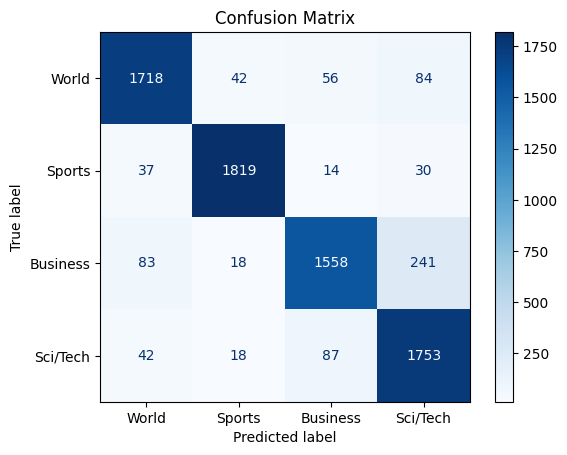

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABELS,
    cmap=plt.cm.Blues,
    colorbar=True
)
plt.title("Confusion Matrix")
plt.show()

# Learnings


* This exercise allowed us to understand how the embeddings and RRN models can be used in a text classification problem. 
* We understood the transformations (assigning to every word an index) that were needed to use the text in the embedding layer, and how the embedding layer was configure to transform the list of indexes into the embeddings.
* We understood how the base class nn.Model allowed us to create a more complex network as long as we connect correctly all the layers in the forward method with the right set of hyperparameters. 

* We learnt how to use mps (Metal Performance Shaders) to train the model using a mac laptop as collab was not available all the time to use the GPUs. Below there's a detail explanation of what MPS is.
    Metal Performance Shaders is a high-performance library created by Apple on top of Metal. Its goal is to ensure you don't have to manually rewrite the same complex GPU kernels over and over, but rather reuse highly fine-tuned implementations for each supported GPU family.

    Metal is Apple's low-level API for 3D graphics and GPU computing, available on iOS, iPadOS, macOS, and tvOS since 2014

* torchtext library is deprectaed and it's not being maintained from 2024, this is causing some compatibility problems with pytorch last version and with numpy.

* During the construction of the RNN, we learnt how to use the embeddings layer and how the expected number of embeddings becomes the input for the RRN and how to calculate using this information the hidden state vector.
* We found that the output of the RRN layer has the out of the W and B for all the sequences but only the last one should be used if we want to pass it to the linear layer. 
* We reinforce the knowledge about confusion matrix and how this is understood.



# Esto de aqui para abajo son solo pruebas que hice para entender como funcionaban algunas cosas de las layers

176

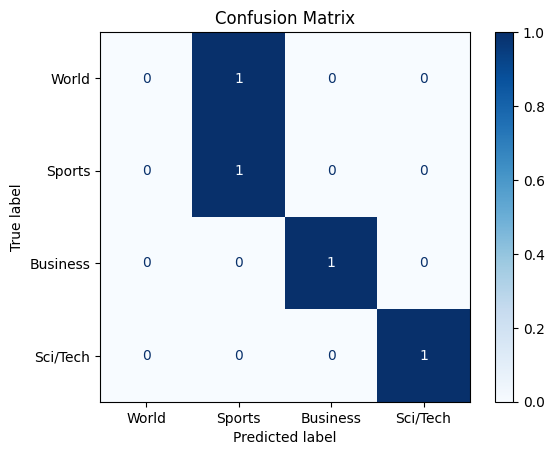

In [70]:
# create confusion matrix
# y_test = np.array([1, 2, 3, 0])
# y_pred = np.array([1,2, 3, 1])

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABELS,
    cmap=plt.cm.Blues,
    colorbar=True
)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch
import torch.nn as nn

# Set random seed for reproducibility
torch.manual_seed(42)

# Parameters
input_size = 5     # Number of features per time step
hidden_size = 10    # Number of features in hidden state
num_layers = 2     # Number of stacked GRU layers
seq_len = 4        # Sequence length
batch_size = 2     # Number of sequences in a batch

# Create a GRU layer
gru = nn.GRU(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=True  # Input/output tensors have shape (batch, seq, feature)
)

# Example input: shape (batch_size, seq_len, input_size)
x = torch.randn(batch_size, seq_len, input_size)

# Initial hidden state: shape (num_layers, batch_size, hidden_size)
h0 = torch.zeros(num_layers, batch_size, hidden_size)
print(h0.shape)

# Forward pass
output, hn = gru(x, h0)

# Output shapes
print("Input shape:", x.shape)         # (2, 4, 5)
print("Output shape:", output.shape)   # (2, 4, 3) -> hidden state for each time step
print("hn shape:", hn.shape)           # (2, 2, 3) -> final hidden state for each layer

# Example: last time step output from top layer
last_output = output[:, -1, :]
print("Last time step output:", last_output)


torch.Size([2, 2, 10])
Input shape: torch.Size([2, 4, 5])
Output shape: torch.Size([2, 4, 10])
hn shape: torch.Size([2, 2, 10])
Last time step output: tensor([[-0.2184,  0.3777,  0.0624, -0.0657,  0.0876,  0.1212, -0.0779,  0.2783,
         -0.2143, -0.3178],
        [-0.2588,  0.5234, -0.0120,  0.0286,  0.1013, -0.0128, -0.0160,  0.1865,
         -0.4536, -0.2002]], grad_fn=<SliceBackward0>)


In [ ]:
output

tensor([[[-0.1743,  0.2173, -0.0674, -0.1453, -0.0273, -0.0589, -0.0024,
           0.0347, -0.2903, -0.0556],
         [-0.2245,  0.3363, -0.1112, -0.1919, -0.0280, -0.1555, -0.0182,
           0.0717, -0.3760, -0.0877],
         [-0.2201,  0.3509,  0.0064, -0.1756,  0.0379, -0.0188, -0.0276,
           0.1408, -0.3035, -0.2093],
         [-0.2184,  0.3777,  0.0624, -0.0657,  0.0876,  0.1212, -0.0779,
           0.2783, -0.2143, -0.3178]],

        [[-0.1503,  0.1943,  0.0423, -0.1542,  0.0911, -0.0940, -0.0038,
           0.0309, -0.1794, -0.0900],
         [-0.2455,  0.3828,  0.0350, -0.0714,  0.1279, -0.0450, -0.0328,
           0.1158, -0.3153, -0.1921],
         [-0.2966,  0.5194, -0.0026,  0.0350,  0.1312,  0.0335, -0.0678,
           0.1853, -0.4364, -0.2345],
         [-0.2588,  0.5234, -0.0120,  0.0286,  0.1013, -0.0128, -0.0160,
           0.1865, -0.4536, -0.2002]]], grad_fn=<TransposeBackward1>)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a custom neural network by inheriting nn.Module
class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNet, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)  # First fully connected layer
        self.fc2 = nn.Linear(hidden_size, output_size) # Second fully connected layer

    def forward(self, x):
        # Define forward pass
        x = F.relu(self.fc1(x))  # Apply ReLU activation
        x = self.fc2(x)          # Output layer
        return x

# Example usage
if __name__ == "__main__":
    model = SimpleNet(input_size=4, hidden_size=8, output_size=3)
    print(model)  # Shows model architecture

    # Create dummy input (batch_size=2, features=4)
    sample_input = torch.randn(2, 4)
    output = model(sample_input)
    print("Output:", output)


SimpleNet(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)
Output: tensor([[0.6806, 0.2465, 0.2361],
        [0.3287, 0.0161, 0.1214]], grad_fn=<AddmmBackward0>)


In [ ]:
h0 = torch.zeros(3, 4, 5)
h0

tensor([[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]])

In [ ]:
for indice, (xi, yi) in enumerate(train_loader):
  # print(xi.size(), yi.size())
  print(yi.size()[0])
  if indice > 5:
    break

256
256
256
256
256
256
256


In [ ]:
len(vocab)

91090

In [ ]:
import torch
import torch.nn as nn

# -----------------------------
# 1. Define parameters
# -----------------------------
vocab_size = 10     # Number of unique tokens (indices 0 to 9)
embedding_dim = 4   # Size of each embedding vector

# -----------------------------
# 2. Create the embedding layer
# -----------------------------
embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

# -----------------------------
# 3. Example input (token indices)
# -----------------------------
# Batch of 2 sequences, each with 3 tokens
# Ensure indices are within [0, vocab_size-1]
input_indices = torch.tensor([[1, 2, 4],
                               [4, 3, 9]], dtype=torch.long)

# -----------------------------
# 4. Forward pass: get embeddings
# -----------------------------
embeddings = embedding_layer(input_indices)

print("Input indices:\n", input_indices)
print("Embeddings shape:", embeddings.shape)  # (batch_size, sequence_length, embedding_dim)
print("Embeddings:\n", embeddings)

# -----------------------------
# 5. Handling out-of-range indices
# -----------------------------
try:
    bad_input = torch.tensor([[1, 10]], dtype=torch.long)  # 10 is out of range
    embedding_layer(bad_input)
except IndexError as e:
    print("Error:", e)


Input indices:
 tensor([[1, 2, 4],
        [4, 3, 9]])
Embeddings shape: torch.Size([2, 3, 4])
Embeddings:
 tensor([[[ 0.5519, -0.8401, -0.3083,  0.9270],
         [-1.7400,  0.8758, -1.3235, -0.8664],
         [-0.2223, -0.5026, -2.0297,  1.7406]],

        [[-0.2223, -0.5026, -2.0297,  1.7406],
         [ 0.3336,  0.7967,  0.8879,  0.0987],
         [-2.2158,  0.8775,  0.3791, -1.9650]]], grad_fn=<EmbeddingBackward0>)
Error: index out of range in self


In [ ]:
train_loader.batch_size

256